# Cube cell example notebook

## Initial set up

#### Get the imports and change the directory

In [1]:
# Set the directory
import os
os.chdir("../..")

In [2]:
# Imports
from System.system import System, Edge, Surface
from Network.build_network import build_network, calc_vert
from Meshes.build_mesh import calc_surf, build_meshes
from Presentation.Visualize.visualize import plot_atoms, plot_verts, plot_surfs, plot_edges
import matplotlib.pyplot as plt

#### Set the atoms' values

In [3]:
# Create atom objects from sets of points
atoms = [[[0, 0, 0], 0.25]]
dist = 3
rad = 2.5

atoms += [[[dist, 0, 0], rad], [[-dist, 0, 0], rad], [[0, dist, 0], rad], [[0, -dist, 0], rad], [[0, 0, dist], rad],
          [[0, 0, -dist], rad]]

#### Create the system

In [4]:
sys = System(atoms)
sys1 = System(atoms)

## Manually create the network

#### Create the vertices

In [5]:
# Calculate the vertices
vert_nums = [[1, 3, 5], [2, 3, 5], [2, 4, 5], [1, 4, 5], [1, 3, 6], [2, 3, 6], [2, 4, 6], [1, 4, 6]]
verts = []
for i in range(8):
    vn = calc_vert([sys.atoms[0], sys.atoms[vert_nums[i][0]], sys.atoms[vert_nums[i][1]], sys.atoms[vert_nums[i][2]]])
    if vn:
        verts.append(vn)
sys.net.verts = verts

#### Create the edges

In [6]:
# Set up the edges' atoms and vertices
e0 = Edge([sys.atoms[0], sys.atoms[3], sys.atoms[5]], [sys.net.verts[0], sys.net.verts[1]])
e1 = Edge([sys.atoms[0], sys.atoms[2], sys.atoms[5]], [sys.net.verts[1], sys.net.verts[2]])
e2 = Edge([sys.atoms[0], sys.atoms[4], sys.atoms[5]], [sys.net.verts[2], sys.net.verts[3]])
e3 = Edge([sys.atoms[0], sys.atoms[1], sys.atoms[5]], [sys.net.verts[3], sys.net.verts[0]])
e4 = Edge([sys.atoms[0], sys.atoms[1], sys.atoms[3]], [sys.net.verts[0], sys.net.verts[4]])
e5 = Edge([sys.atoms[0], sys.atoms[2], sys.atoms[3]], [sys.net.verts[1], sys.net.verts[5]])
e6 = Edge([sys.atoms[0], sys.atoms[2], sys.atoms[4]], [sys.net.verts[2], sys.net.verts[6]])
e7 = Edge([sys.atoms[0], sys.atoms[1], sys.atoms[4]], [sys.net.verts[3], sys.net.verts[7]])
e8 = Edge([sys.atoms[0], sys.atoms[3], sys.atoms[6]], [sys.net.verts[4], sys.net.verts[5]])
e9 = Edge([sys.atoms[0], sys.atoms[2], sys.atoms[6]], [sys.net.verts[5], sys.net.verts[6]])
e10 = Edge([sys.atoms[0], sys.atoms[4], sys.atoms[6]], [sys.net.verts[6], sys.net.verts[7]])
e11 = Edge([sys.atoms[0], sys.atoms[1], sys.atoms[6]], [sys.net.verts[7], sys.net.verts[4]])
sys.net.edges = [e0, e1, e2, e3, e4, e5, e6, e7, e8, e9, e10, e11]

#### Set the vertices edges

In [7]:
# Set the vertices' edges
sys.net.verts[0].edges = [e0, e3, e4, None]
sys.net.verts[1].edges = [e0, e1, e5, None]
sys.net.verts[2].edges = [e1, e2, e6, None]
sys.net.verts[3].edges = [e2, e3, e7, None]
sys.net.verts[4].edges = [e4, e8, e11, None]
sys.net.verts[5].edges = [e5, e8, e9, None]
sys.net.verts[6].edges = [e6, e9, e10, None]
sys.net.verts[7].edges = [e7, e10, e11, None]

#### Create the surfaces

In [8]:
# Set up the surfaces' atoms
s0 = Surface([sys.atoms[0], sys.atoms[5]], calc_surf([sys.atoms[0], sys.atoms[5]]))
s1 = Surface([sys.atoms[0], sys.atoms[3]], calc_surf([sys.atoms[0], sys.atoms[3]]))
s2 = Surface([sys.atoms[0], sys.atoms[2]], calc_surf([sys.atoms[0], sys.atoms[2]]))
s3 = Surface([sys.atoms[0], sys.atoms[4]], calc_surf([sys.atoms[0], sys.atoms[4]]))
s4 = Surface([sys.atoms[0], sys.atoms[1]], calc_surf([sys.atoms[0], sys.atoms[1]]))
s5 = Surface([sys.atoms[0], sys.atoms[6]], calc_surf([sys.atoms[0], sys.atoms[6]]))
sys.net.surfs = [s0, s1, s2, s3, s4, s5]

#### Set the surfaces' vertices

In [9]:
sys.net.surfs[0].verts = sys.net.verts[0], sys.net.verts[1], sys.net.verts[2], sys.net.verts[3]
sys.net.surfs[1].verts = sys.net.verts[0], sys.net.verts[1], sys.net.verts[4], sys.net.verts[5]
sys.net.surfs[2].verts = sys.net.verts[1], sys.net.verts[2], sys.net.verts[5], sys.net.verts[6]
sys.net.surfs[3].verts = sys.net.verts[2], sys.net.verts[3], sys.net.verts[6], sys.net.verts[7]
sys.net.surfs[4].verts = sys.net.verts[0], sys.net.verts[3], sys.net.verts[4], sys.net.verts[7]
sys.net.surfs[5].verts = sys.net.verts[4], sys.net.verts[5], sys.net.verts[6], sys.net.verts[7]

#### Set the surfaces' edges

In [10]:
sys.net.surfs[0].edges = [e0, e1, e2, e3]
sys.net.surfs[1].edges = [e0, e4, e5, e8]
sys.net.surfs[2].edges = [e1, e5, e6, e9]
sys.net.surfs[3].edges = [e2, e6, e7, e10]
sys.net.surfs[4].edges = [e3, e4, e7, e11]
sys.net.surfs[5].edges = [e8, e9, e10, e11]

## Build the network using build_network

In [11]:
build_network(sys1)

In [12]:
print(sys1.net.verts)

[<System.net_objects.Vertex object at 0x0000014899152B80>, <System.net_objects.Vertex object at 0x00000148991528B0>, <System.net_objects.Vertex object at 0x0000014899152310>, <System.net_objects.Vertex object at 0x0000014899152E20>, <System.net_objects.Vertex object at 0x0000014899152430>, <System.net_objects.Vertex object at 0x0000014899152D00>, <System.net_objects.Vertex object at 0x0000014899152D30>, <System.net_objects.Vertex object at 0x00000148991529A0>]


## Build the cells

In [18]:
build_meshes(sys)
build_meshes(sys1)

SyntaxError: invalid syntax (Temp/ipykernel_18956/3601999253.py, line 2)

## Plot the results

<IPython.core.display.Javascript object>


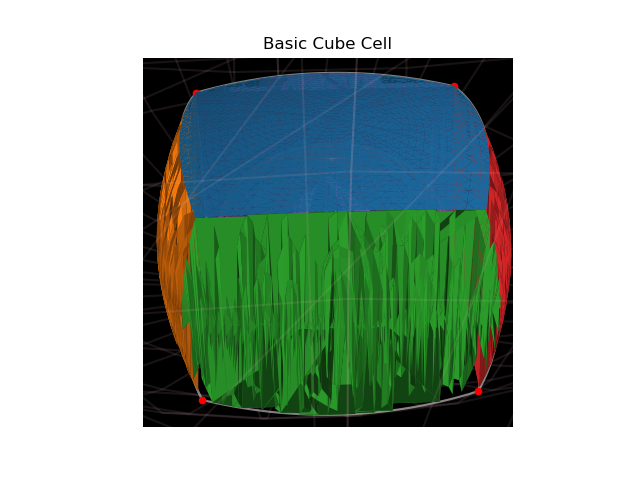

In [17]:
# Set up the plot
%matplotlib notebook
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.set_title("Basic Cube Cell")
# Plot the elements of the network
plot_atoms(sys.atoms[:4], fig=fig, ax=ax, dfo=2, alpha=0.1)
plot_verts(sys.net.verts, fig=fig, ax=ax, colors=['r' for i in range(8)])
plot_edges(sys.net.edges, fig=fig, ax=ax)
plot_surfs(sys.net.surfs[:-1], fig=fig, ax=ax, Show=True, dfo=10)